## D1.2 – Project Submission

In [1]:
import kagglehub
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\js834\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("muratkokludataset/dry-bean-dataset")
archivos = glob.glob(os.path.join(path, "**", "*.xlsx"), recursive=True)

archivo_datos = archivos[0]
df = pd.read_excel(archivo_datos)

display(df.head()) 

df.info() 

duplicate_count = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

### 1. Data Processing

Cleaning

In [3]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Shape original:", df.shape)
print("Shape sin duplicados:", df_clean.shape)

Shape original: (13611, 17)
Shape sin duplicados: (13543, 17)


Split train and test

In [4]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["Class"])
y = df_clean["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Standarization

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])


### 2. Imbalance Analysis and Mitigation 


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_counts = y_train.value_counts()
train_percent = y_train.value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({
    "count": train_counts,
    "percentage": train_percent.round(2)
})

display(imbalance_summary)

imbalance_ratio = train_counts.max() / train_counts.min()
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")


,count,percentage
Class,,
DERMASON,2837,26.19
SIRA,2109,19.47
SEKER,1621,14.96
HOROZ,1488,13.73
CALI,1304,12.04
BARBUNYA,1057,9.76
BOMBAY,418,3.86


Imbalance ratio (majority/minority): 6.79


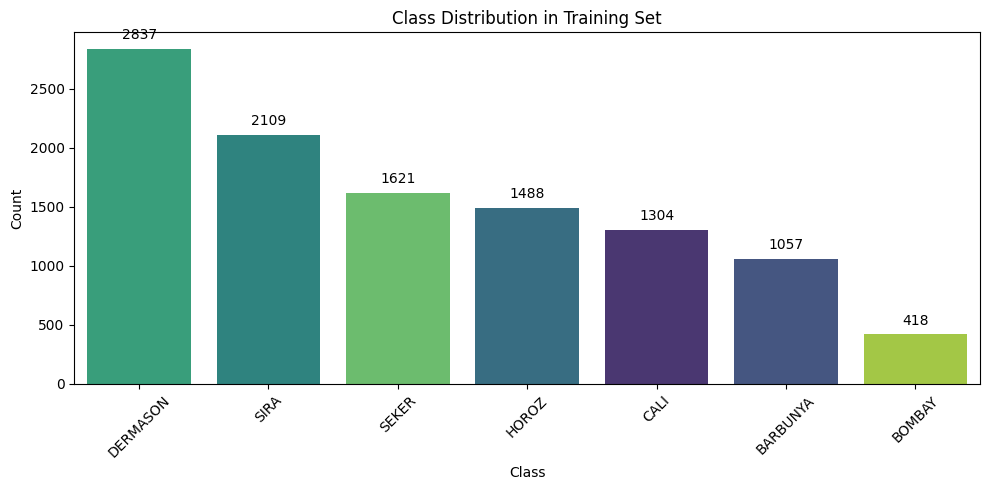

In [7]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    x=y_train,
    order=y_train.value_counts().index,
    hue=y_train,
    palette="viridis",
    legend=False
)

plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [9]:
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

In [10]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

In [11]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

C:\Users\js834\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\js834\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^

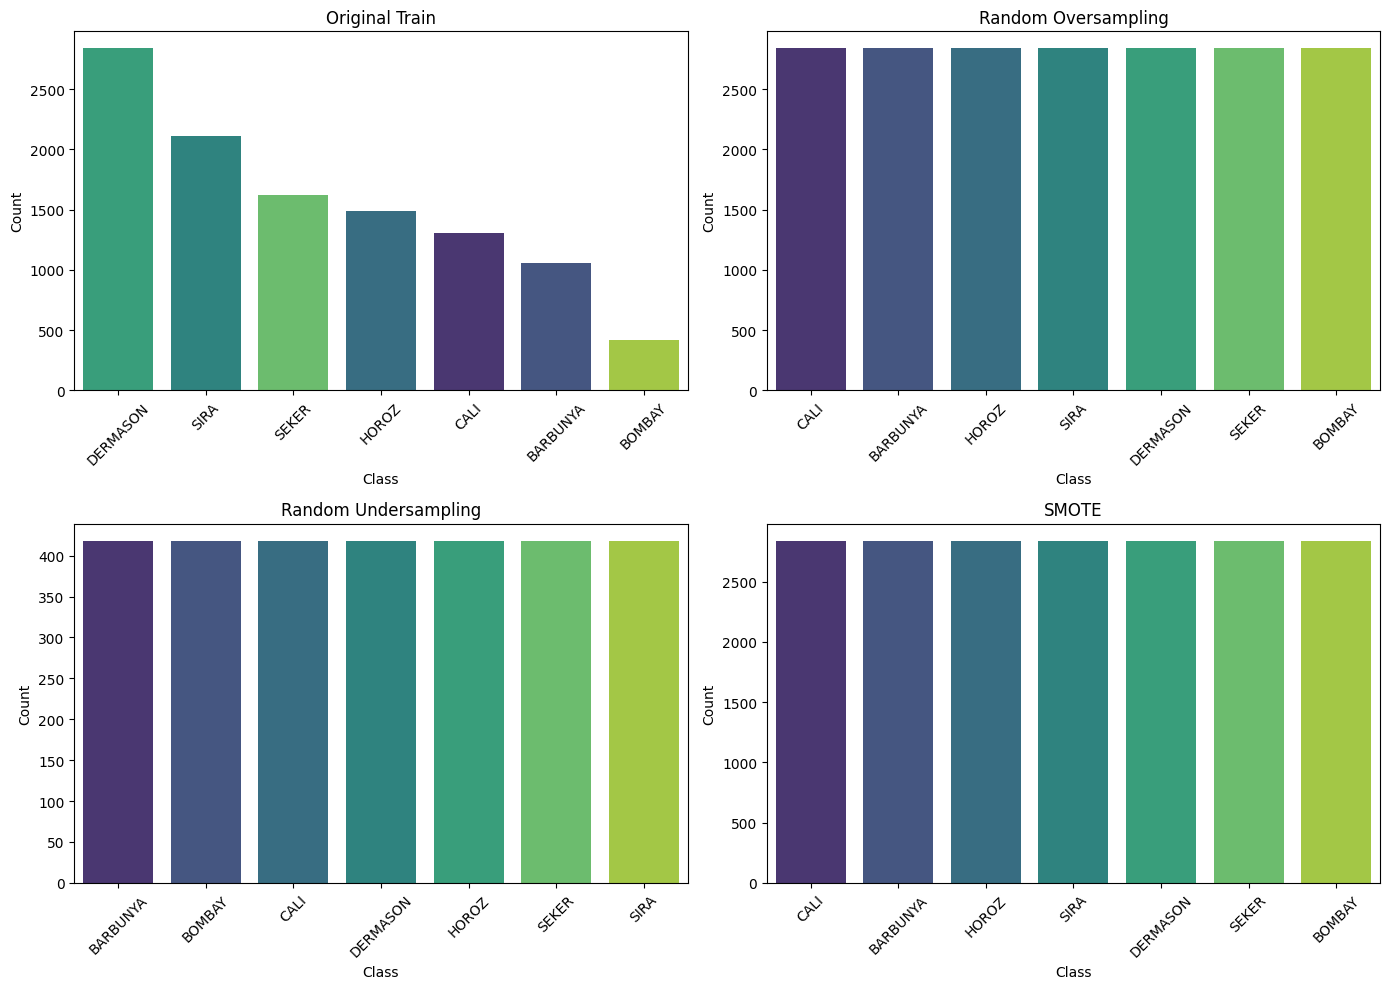

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets = {
    "Original Train": y_train,
    "Random Oversampling": y_train_over,
    "Random Undersampling": y_train_under,
    "SMOTE": y_train_smote
}

for ax, (title, y_data) in zip(axes.flatten(), datasets.items()):
    order = y_data.value_counts().index
    sns.countplot(
        x=y_data,
        order=order,
        hue=y_data,
        palette="viridis",
        legend=False,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [13]:
summary_resampling = pd.DataFrame({
    "Original": y_train.value_counts(),
    "Oversampling": y_train_over.value_counts(),
    "Undersampling": y_train_under.value_counts(),
    "SMOTE": y_train_smote.value_counts()
}).fillna(0).astype(int)

display(summary_resampling)


,Original,Oversampling,Undersampling,SMOTE
Class,,,,
BARBUNYA,1057,2837,418,2837
BOMBAY,418,2837,418,2837
CALI,1304,2837,418,2837
DERMASON,2837,2837,418,2837
HOROZ,1488,2837,418,2837
SEKER,1621,2837,418,2837
SIRA,2109,2837,418,2837


3. Model Comparison and Hyperparameter Tuning 